# Real Estate Market Analysis - Task 4
## Data Visualization

### Step 1: Load Merged Dataset

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

base_path = Path('/workspaces/real-estate-market-analysis')

# Load merged data
df = pd.read_csv(base_path / 'data/processed/merged_real_estate.csv')

# Calculate age if not present
if 'age' not in df.columns:
    print("⚠️ 'age' column not found. Calculating now...")
    
    # Convert dates
    df['birth_date'] = pd.to_datetime(df['birth_date'], errors='coerce')
    
    # Find date column
    if 'date' in df.columns:
        df['date_sale'] = pd.to_datetime(df['date'], errors='coerce')
    elif 'date_sale' in df.columns:
        df['date_sale'] = pd.to_datetime(df['date_sale'], errors='coerce')
    
    # Calculate age
    df['age'] = df['date_sale'].dt.year - df['birth_date'].dt.year
    df.loc[df['date_sale'].dt.month < df['birth_date'].dt.month, 'age'] -= 1
    
    print(f"✅ Age calculated. Range: {df['age'].min():.0f} - {df['age'].max():.0f}")
    
    # Save back to CSV
    df.to_csv(base_path / 'data/processed/merged_real_estate.csv', index=False)
    print("✅ Age column saved to merged dataset")
else:
    print("✅ 'age' column already exists")

print(f"\nDataset shape: {df.shape}")
print(f"Columns with age: {'age' in df.columns}")

⚠️ 'age' column not found. Calculating now...
✅ Age calculated. Range: 19 - 76
✅ Age column saved to merged dataset

Dataset shape: (195, 23)
Columns with age: True


In [5]:
import pandas as pd
import sys
from pathlib import Path

# Set correct path
base_path = Path('/workspaces/real-estate-market-analysis')

# Load merged data
df = pd.read_csv(base_path / 'data/processed/merged_real_estate.csv')

print(f"✅ Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")

✅ Loaded dataset: 195 rows, 23 columns


### Step 2: Import Visualization Module

In [6]:
sys.path.insert(0, str(base_path))

from src.visualization.charts import RealEstateVisualizer

print("✅ Visualization module imported")

✅ Visualization module imported


### Step 3: Run All Visualizations


🎨 TASK 4: GENERATING VISUALIZATIONS

1️⃣ Deal Satisfaction by Country...


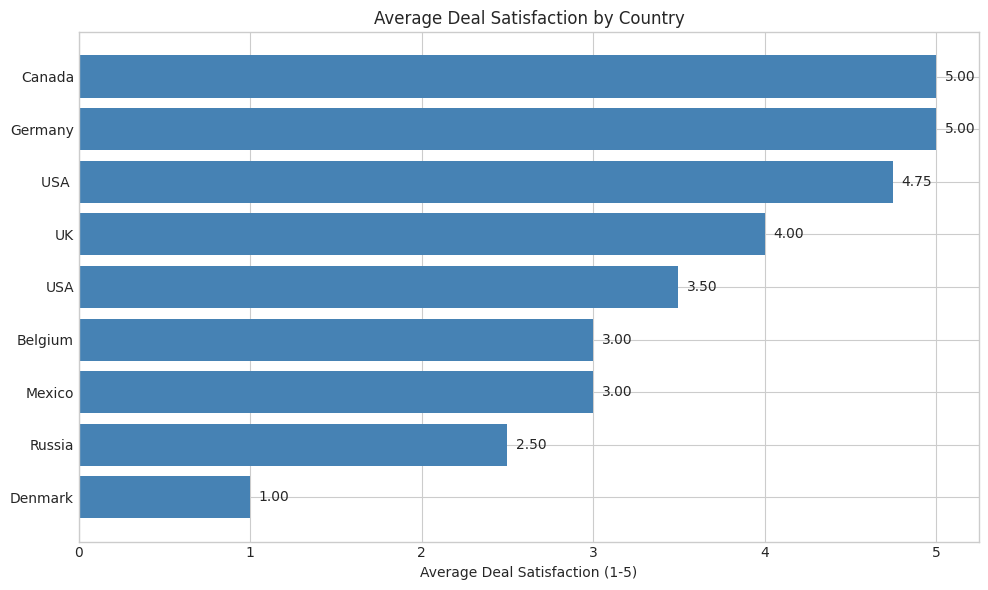

✅ Saved: reports/satisfaction_by_country.png

2️⃣ Monthly Revenue...


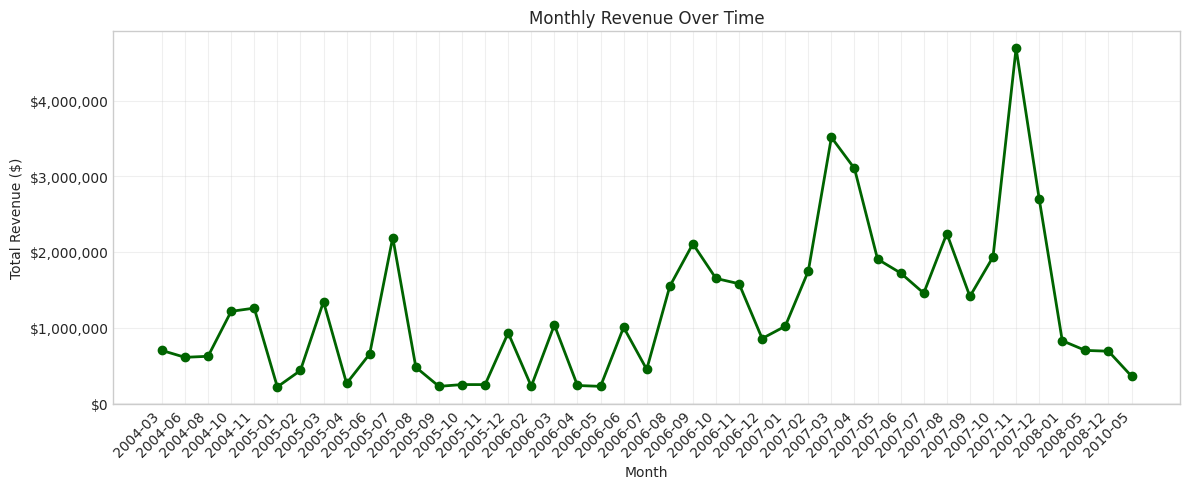

✅ Saved: reports/monthly_revenue.png

3️⃣ Apartments Sold by State (Pareto)...


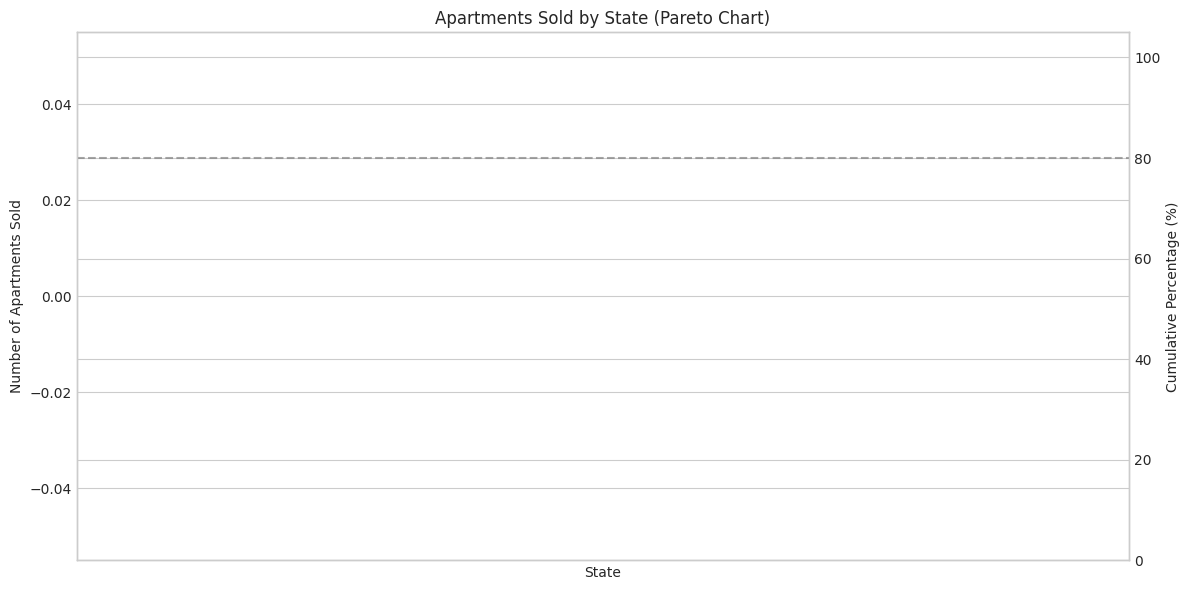

✅ Saved: reports/apartments_by_state_pareto.png

4️⃣ Age Distribution...


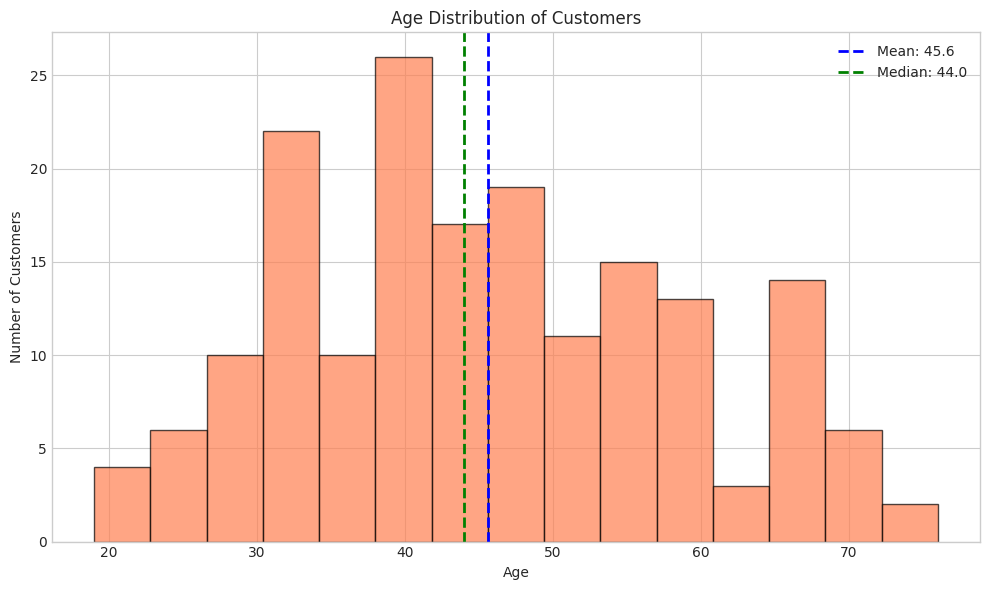

✅ Saved: reports/age_distribution.png

5️⃣ Yearly Sales by Building...


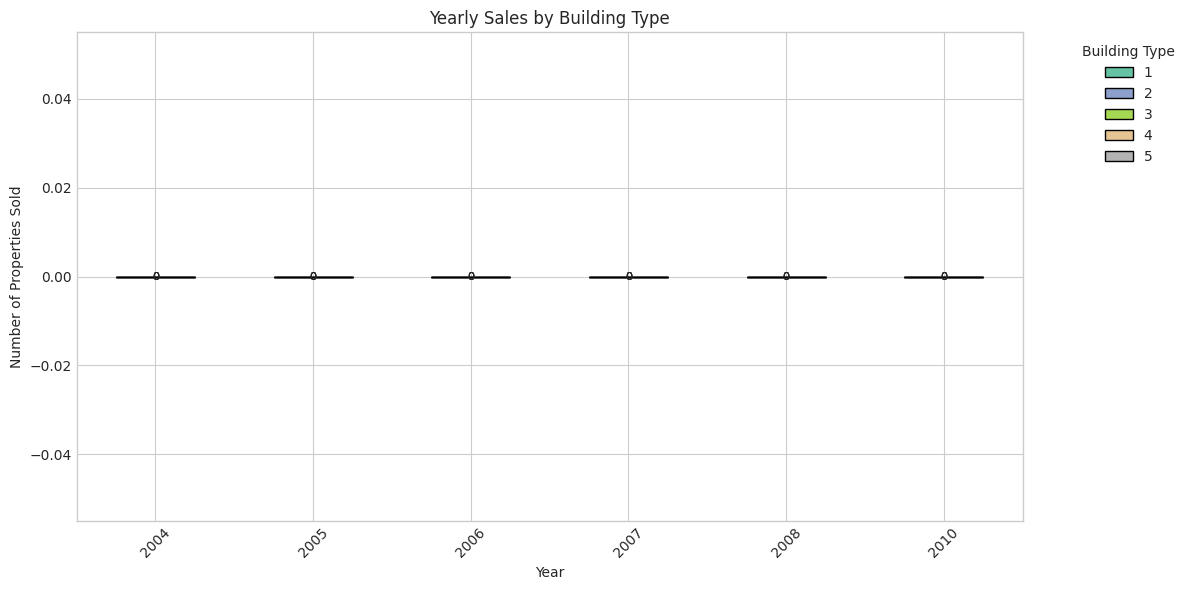

✅ Saved: reports/yearly_sales_by_building.png

✅ TASK 4 COMPLETE! All visualizations saved to reports/


In [7]:
# Initialize visualizer
viz = RealEstateVisualizer(df)

# Generate all 5 visualizations
results = viz.run_all_visualizations()

### Step 4: Verify Generated Files

In [8]:
import os

print("\n📁 Generated Visualization Files:")
print("="*50)

files = [
    'satisfaction_by_country.png',
    'monthly_revenue.png', 
    'apartments_by_state_pareto.png',
    'age_distribution.png',
    'yearly_sales_by_building.png'
]

for f in files:
    path = base_path / 'reports' / f
    if path.exists():
        size = path.stat().st_size / 1024
        print(f"✅ {f} ({size:.1f} KB)")
    else:
        print(f"❌ {f} - NOT FOUND")


📁 Generated Visualization Files:
✅ satisfaction_by_country.png (124.1 KB)
✅ monthly_revenue.png (256.7 KB)
✅ apartments_by_state_pareto.png (114.1 KB)
✅ age_distribution.png (93.2 KB)
✅ yearly_sales_by_building.png (106.5 KB)


## ✅ TASK 4 COMPLETE

In [9]:
print("\n" + "="*60)
print("✅ TASK 4 COMPLETED SUCCESSFULLY")
print("="*60)
print("\nGenerated Visualizations:")
print("  1. satisfaction_by_country.png - Bar chart")
print("  2. monthly_revenue.png - Time-series line graph")
print("  3. apartments_by_state_pareto.png - Pareto chart")
print("  4. age_distribution.png - Histogram")
print("  5. yearly_sales_by_building.png - Stacked bar chart")
print("\n📁 All images saved to reports/ folder")
print("\n➡️ Ready for Task 5: Data Interpretation")


✅ TASK 4 COMPLETED SUCCESSFULLY

Generated Visualizations:
  1. satisfaction_by_country.png - Bar chart
  2. monthly_revenue.png - Time-series line graph
  3. apartments_by_state_pareto.png - Pareto chart
  4. age_distribution.png - Histogram
  5. yearly_sales_by_building.png - Stacked bar chart

📁 All images saved to reports/ folder

➡️ Ready for Task 5: Data Interpretation
